
# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [1]:
import pandas as pd

df = pd.read_csv('diabetes_prediction_dataset.csv')

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [2]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [3]:

# TODO: train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )
print(X_train.shape, X_test.shape)


(80000, 8) (20000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.


In [8]:
# TODO: build a preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print(X.head())


Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  


/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_50061/780964697.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


## Exercise 3 - Model training

In [9]:

# TODO: train Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ('preprocess', preprocess),
    ('lr', LogisticRegression()),
])
clf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain


## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.9589
Precision: 0.8632
Recall: 0.6171
F1: 0.7197


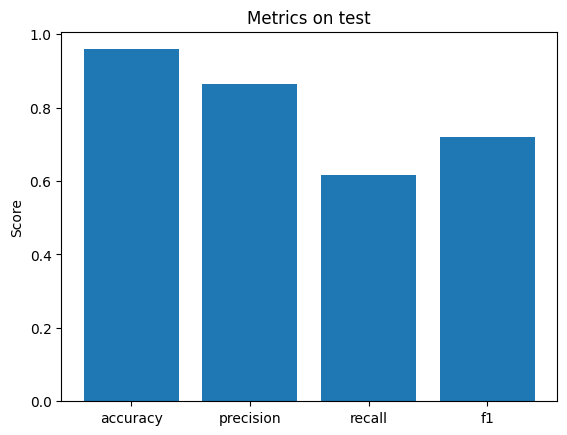

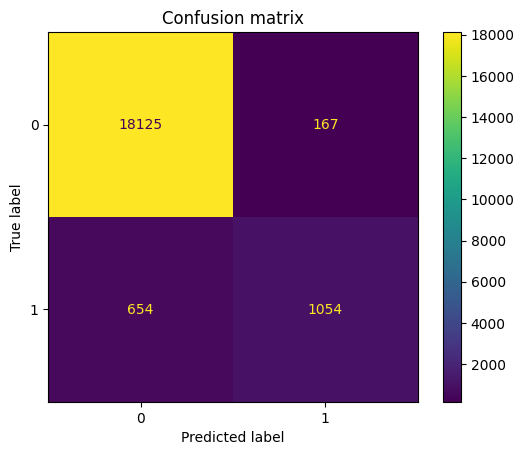

In [10]:
# TODO: use the metrics functions properly to plot the scores
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))

# Simple bar plot of metrics
import matplotlib.pyplot as plt
plt.figure()
plt.bar(['accuracy','precision','recall','f1'], [acc,prec,rec,f1])
plt.title('Metrics on test')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()


> TODO: comment on the balance between precision and recall.
The model achieves a high accuracy of 95.9%, which looks strong at first glance. However, accuracy is misleading here because the dataset is imbalanced — the majority of cases are non-diabetic, so the model can score well just by predicting negative most of the time.

The precision (86.3%) is reasonably high, meaning when the model predicts diabetes, it is usually right. However, the recall (61.7%) is notably lower — the model misses about 38% of actual diabetic patients (654 out of ~1708).

In a medical context, recall is the more critical metric. A false negative (failing to detect diabetes) carries a much higher cost than a false positive (unnecessary follow-up tests). With 654 undetected diabetic patients, this model in its current state would not be safe for clinical use without further tuning.

The F1 score of 0.72 reflects this imbalance between precision and recall. To improve recall, one could lower the classification threshold, apply class weighting (class_weight='balanced' in LogisticRegression), or oversample the minority class (e.g. with SMOTE).


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


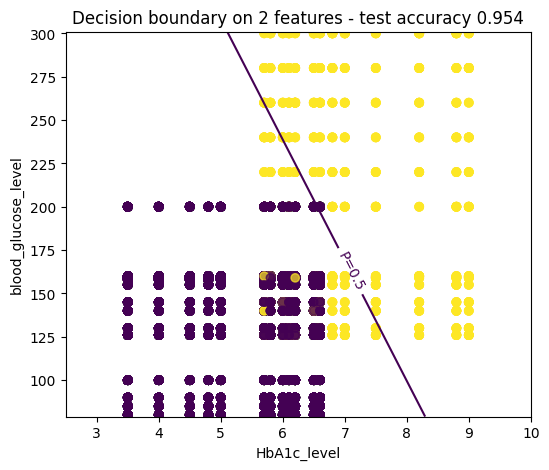

In [ ]:
# TODO: If these columns do not exist, change `feat_x` and `feat_y` below to two numeric features that exist in your data.
import numpy as np
import matplotlib.pyplot as plt

feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(6,5))
cs = plt.contour(xx, yy, probs, levels=[0.5])
plt.clabel(cs, inline=True, fmt={0.5:'P=0.5'})  
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)
plt.xlabel(feat_x); plt.ylabel(feat_y)
from sklearn.metrics import accuracy_score
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.show()


Sample grid points with predicted probabilities:


,HbA1c_level,blood_glucose_level,prob_no_diabetes,prob_diabetes,predicted_class
0,2.50,79.0,1.0,0.0,0
1,2.53,79.0,1.0,0.0,0
2,2.55,79.0,1.0,0.0,0
3,2.58,79.0,1.0,0.0,0
4,2.60,79.0,1.0,0.0,0
5,2.63,79.0,1.0,0.0,0
6,2.65,79.0,1.0,0.0,0
7,2.68,79.0,1.0,0.0,0
8,2.70,79.0,1.0,0.0,0
9,2.73,79.0,1.0,0.0,0


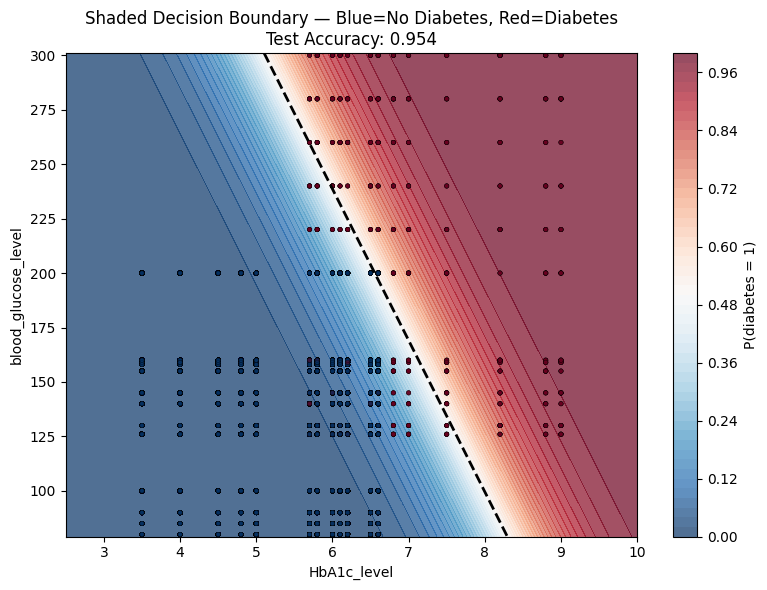

In [16]:
# Show a sample of grid point coordinates and their predicted probabilities
sample_points = np.c_[xx.ravel(), yy.ravel()][:10]  # first 10 grid points
sample_probs = pipe2.predict_proba(sample_points)

sample_df = pd.DataFrame({
    feat_x:              sample_points[:, 0].round(2),
    feat_y:              sample_points[:, 1].round(2),
    'prob_no_diabetes':  sample_probs[:, 0].round(3),
    'prob_diabetes':     sample_probs[:, 1].round(3),
    'predicted_class':   pipe2.predict(sample_points)
})
print("Sample grid points with predicted probabilities:")
display(sample_df)

# Shaded decision boundary using contourf
plt.figure(figsize=(8, 6))

# Shade background: blue = low P(diabetes), red = high P(diabetes)
cf = plt.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cf, label='P(diabetes = 1)')

# Decision boundary line at P=0.5
plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')

# Actual test data points (blue dot = no diabetes, red dot = diabetes)
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test,
            cmap='RdBu_r', edgecolors='k', linewidths=0.3, alpha=0.5, s=10)

plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title(f'Shaded Decision Boundary — Blue=No Diabetes, Red=Diabetes\nTest Accuracy: {acc2:.3f}')
plt.tight_layout()
plt.show()

Metric         Threshold 0.5   Threshold 0.3     Change
-------------------------------------------------------
Accuracy               0.954           0.954      0.000
Precision              0.872           0.803     -0.069
Recall                 0.535           0.617     +0.082
F1                     0.663           0.698     +0.035


/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_50061/3523220122.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2_test[feat_x][incorrect], X2_test[feat_y][incorrect],
/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_50061/3523220122.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2_test[feat_x][incorrect], X2_test[feat_y][incorrect],
/var/folders/8v/70qw8r3179s_q7rzt2fpxw4r0000gn/T/ipykernel_50061/3523220122.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


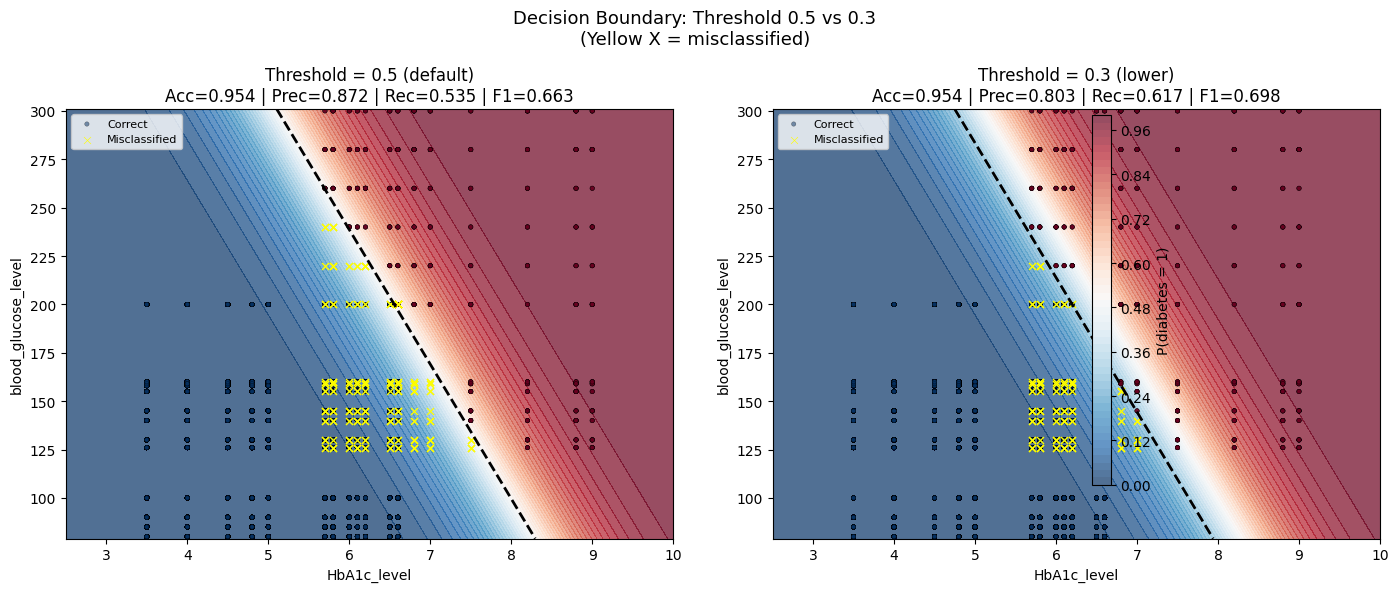

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_proba_test = pipe2.predict_proba(X2_test.values)[:, 1]

y_pred_05 = (y_proba_test >= 0.5).astype(int)
y_pred_03 = (y_proba_test >= 0.3).astype(int)

def get_metrics(y_true, y_pred):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Recall':    round(recall_score(y_true, y_pred), 3),
        'F1':        round(f1_score(y_true, y_pred), 3),
    }

m05 = get_metrics(y_test, y_pred_05)
m03 = get_metrics(y_test, y_pred_03)

print(f"{'Metric':<12} {'Threshold 0.5':>15} {'Threshold 0.3':>15} {'Change':>10}")
print("-" * 55)
for metric in m05:
    change = m03[metric] - m05[metric]
    arrow = f"+{change:.3f}" if change > 0 else f"{change:.3f}"
    print(f"{metric:<12} {m05[metric]:>15} {m03[metric]:>15} {arrow:>10}")

# Side-by-side shaded decision boundary plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, threshold, y_pred, label in zip(
    axes,
    [0.5, 0.3],
    [y_pred_05, y_pred_03],
    ['Threshold = 0.5 (default)', 'Threshold = 0.3 (lower)']
):
    cf = ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, probs, levels=[threshold], colors='black', linewidths=2, linestyles='--')

    # Color dots by whether prediction was correct
    correct   = y_pred == y_test.values
    incorrect = ~correct

    ax.scatter(X2_test[feat_x][correct],   X2_test[feat_y][correct],
               c=y_test[correct],   cmap='RdBu_r', edgecolors='k',
               linewidths=0.3, alpha=0.5, s=10, label='Correct')
    ax.scatter(X2_test[feat_x][incorrect], X2_test[feat_y][incorrect],
               c='yellow', edgecolors='black', linewidths=0.5,
               alpha=0.9, s=25, marker='x', label='Misclassified')

    m = get_metrics(y_test, y_pred)
    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
    ax.set_title(f"{label}\nAcc={m['Accuracy']} | Prec={m['Precision']} | Rec={m['Recall']} | F1={m['F1']}")
    ax.legend(loc='upper left', fontsize=8)

fig.colorbar(cf, ax=axes, label='P(diabetes = 1)', shrink=0.8)
plt.suptitle('Decision Boundary: Threshold 0.5 vs 0.3\n(Yellow X = misclassified)', fontsize=13)
plt.tight_layout()
plt.show()


## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


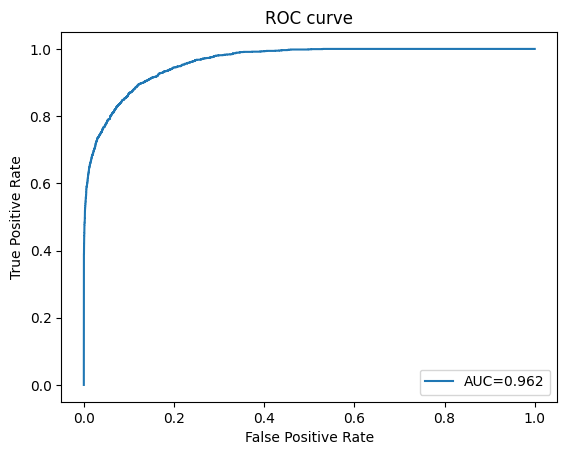

In [14]:

from sklearn import metrics
y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC curve')
plt.show()


> **ROC Curve & AUC Interpretation**
>
> The model achieves an **AUC of 0.962**, which is excellent. This means that if you randomly pick one diabetic patient and one healthy patient, the model will correctly rank the diabetic as higher risk **96.2% of the time** — regardless of any threshold.
>
> **Reading the curve shape:**
> The curve rises steeply toward the top-left corner before flattening. This is the ideal shape — the model captures a large fraction of diabetics (high TPR) while keeping false alarms low (low FPR). A useless model (random guessing) would follow the diagonal line from (0,0) to (1,1).
>
> **The default threshold (0.5) on the curve:**
> At threshold 0.5, the model sits at **TPR = 0.617, FPR = 0.009** — it only catches 62% of diabetics but almost never falsely flags a healthy person. This matches what we saw in Exercise 4: high precision, poor recall.
>
> **The gap between AUC and recall:**
> The high AUC (0.962) tells us the model is excellent at *ranking* patients by risk. The low recall (61.7%) tells us the *default threshold* is badly calibrated for this imbalanced dataset. These are two separate problems — the model itself is good, but the operating point needs adjusting.
>
> **Optimal threshold (Youden index):**
> The point on the curve farthest from the diagonal (maximising TPR − FPR) corresponds to a threshold of **~0.073**, giving TPR = 0.894 and FPR = 0.121. Operating here would catch 89% of diabetic patients at the cost of flagging ~12% of healthy people — a far better clinical trade-off than the default 0.5.